<a href="https://colab.research.google.com/github/prapakronmu/PythonDataViz2026/blob/main/Pandas102S9_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

path = '/content/drive/My Drive/dataviz_2026_data'

covid_file_path = os.path.join(path,'confirmed-cases-since-120465.csv')
print(covid_file_path)

/content/drive/My Drive/dataviz_2026_data/confirmed-cases-since-120465.csv


In [5]:
data_covid = pd.read_csv(covid_file_path)
data_covid.head()

/tmp/ipykernel_1068/1799772574.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  data_covid = pd.read_csv(covid_file_path)


,No.,announce_date,Notified date,sex,age,Unit,nationality,province_of_isolation,risk,province_of_onset,district_of_onset
0,3905873,12/4/2022,11/4/2022,หญิง,54.0,ปี,Thailand,เชียงใหม่,อยู่ระหว่างการสอบสวน,เชียงใหม่,จอมทอง
1,3905874,12/4/2022,11/4/2022,หญิง,36.0,ปี,Thailand,เชียงใหม่,อยู่ระหว่างการสอบสวน,เชียงใหม่,เมืองเชียงใหม่
2,3905875,12/4/2022,11/4/2022,หญิง,31.0,ปี,Thailand,เชียงใหม่,อยู่ระหว่างการสอบสวน,เชียงใหม่,ดอยหล่อ
3,3905876,12/4/2022,11/4/2022,ชาย,37.0,ปี,Thailand,เชียงใหม่,อยู่ระหว่างการสอบสวน,NaN,ต่างจังหวัด
4,3905877,12/4/2022,11/4/2022,หญิง,33.0,ปี,Thailand,เชียงใหม่,อยู่ระหว่างการสอบสวน,เชียงใหม่,แม่ริม


# .isnull()?? None??  

In [6]:
data_covid.isnull()

,No.,announce_date,Notified date,sex,age,Unit,nationality,province_of_isolation,risk,province_of_onset,district_of_onset
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
356607,False,False,False,False,True,True,True,False,False,True,True
356608,False,False,False,False,True,True,True,False,False,True,True
356609,False,False,False,False,True,True,True,False,False,True,True
356610,False,False,False,False,True,True,True,False,False,True,True


.any() เอาค่าความจริงภายในแต่ละ column มา ```OR``` กัน  

In [7]:
data_covid.isnull().any()

,0
No.,False
announce_date,False
Notified date,False
sex,True
age,True
Unit,True
nationality,True
province_of_isolation,False
risk,False
province_of_onset,True


.all() เอาค่าความจริงภายในแต่ละ column มา ```AND``` กัน  

In [8]:
data_covid.isnull().all()

,0
No.,False
announce_date,False
Notified date,False
sex,False
age,False
Unit,False
nationality,False
province_of_isolation,False
risk,False
province_of_onset,False


In [11]:
import pandas as pd
pd.isna(data_covid.iloc[0,0])

False

In [12]:
data_covid['No.'][0].isnull()

AttributeError: 'numpy.int64' object has no attribute 'isnull'

In [13]:
data_covid.iloc[0,0]

np.int64(3905873)

In [14]:
data_covid.iloc[:1,0].isnull()

,No.
0,False


# ต่อตารางแกน X แกน y


*   ต่อแกน y คือ เพิ่ม records (เพิ่มจำนวนข้อมูล)
*   ต่อแกน x คือ เพิ่ม columns (เพิ่มรายละเอียดของข้อมูล)



## ต่อแกน Y pd.concat()

In [15]:
data_covid['province_of_onset']=='ขอนแก่น'

,province_of_onset
0,False
1,False
2,False
3,False
4,False
...,...
356607,False
356608,False
356609,False
356610,False


In [16]:
dataKK = data_covid[data_covid['province_of_onset']=='ขอนแก่น']
dataKK.head()

,No.,announce_date,Notified date,sex,age,Unit,nationality,province_of_isolation,risk,province_of_onset,district_of_onset
3345,3909218,12/4/2022,11/4/2022,หญิง,27.0,ปี,Thailand,พระนครศรีอยุธยา,สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้,ขอนแก่น,บ้านไผ่
3763,3909636,12/4/2022,11/4/2022,หญิง,47.0,ปี,Thailand,ปทุมธานี,ไปสถานที่ชุมชน เช่น ตลาดนัด สถานที่ท่องเที่ยว,ขอนแก่น,บ้านไผ่
3823,3909696,12/4/2022,11/4/2022,ชาย,53.0,ปี,Thailand,สระบุรี,ระบุไม่ได้,ขอนแก่น,น้ำพอง
8436,3914309,12/4/2022,11/4/2022,หญิง,35.0,ปี,Thailand,ระยอง,อยู่ระหว่างการสอบสวน,ขอนแก่น,มัญจาคีรี
10537,3916410,12/4/2022,11/4/2022,หญิง,32.0,ปี,Thailand,ขอนแก่น,สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้,ขอนแก่น,อุบลรัตน์


In [17]:
dataUD = data_covid[data_covid['province_of_onset']=='อุดรธานี']
dataUD.head()

,No.,announce_date,Notified date,sex,age,Unit,nationality,province_of_isolation,risk,province_of_onset,district_of_onset
3025,3908898,12/4/2022,11/4/2022,ชาย,51.0,ปี,Thailand,นนทบุรี,สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้,อุดรธานี,บ้านดุง
3759,3909632,12/4/2022,11/4/2022,ชาย,26.0,ปี,Thailand,ปทุมธานี,ไปสถานที่ชุมชน เช่น ตลาดนัด สถานที่ท่องเที่ยว,อุดรธานี,ทุ่งฝน
8454,3914327,12/4/2022,11/4/2022,ชาย,32.0,ปี,Thailand,ระยอง,อยู่ระหว่างการสอบสวน,อุดรธานี,กุดจับ
9640,3915513,12/4/2022,11/4/2022,ชาย,32.0,ปี,Thailand,ตราด,อยู่ระหว่างการสอบสวน,อุดรธานี,เมืองอุดรธานี
11064,3916937,12/4/2022,11/4/2022,ชาย,NaN,NaN,Thailand,อุดรธานี,อื่นๆ,อุดรธานี,หนองวัวซอ


In [18]:
dataMS = data_covid[data_covid['province_of_onset']=='มหาสารคาม']
dataMS.head()

,No.,announce_date,Notified date,sex,age,Unit,nationality,province_of_isolation,risk,province_of_onset,district_of_onset
8248,3914121,12/4/2022,11/4/2022,หญิง,9.0,ปี,Thailand,ระยอง,อยู่ระหว่างการสอบสวน,มหาสารคาม,บรบือ
10064,3915937,12/4/2022,11/4/2022,ชาย,32.0,ปี,Thailand,มหาสารคาม,บุคลากรด้านการแพทย์และสาธารณสุข,มหาสารคาม,กันทรวิชัย
10065,3915938,12/4/2022,11/4/2022,ชาย,77.0,ปี,Thailand,มหาสารคาม,สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้,มหาสารคาม,กันทรวิชัย
10066,3915939,12/4/2022,11/4/2022,ชาย,50.0,ปี,Thailand,มหาสารคาม,อื่นๆ,มหาสารคาม,กันทรวิชัย
10067,3915940,12/4/2022,11/4/2022,หญิง,49.0,ปี,Thailand,มหาสารคาม,อื่นๆ,มหาสารคาม,กันทรวิชัย


In [19]:
dataMYisan = pd.concat([dataKK,dataUD,dataMS])
dataMYisan

,No.,announce_date,Notified date,sex,age,Unit,nationality,province_of_isolation,risk,province_of_onset,district_of_onset
3345,3909218,12/4/2022,11/4/2022,หญิง,27.0,ปี,Thailand,พระนครศรีอยุธยา,สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้,ขอนแก่น,บ้านไผ่
3763,3909636,12/4/2022,11/4/2022,หญิง,47.0,ปี,Thailand,ปทุมธานี,ไปสถานที่ชุมชน เช่น ตลาดนัด สถานที่ท่องเที่ยว,ขอนแก่น,บ้านไผ่
3823,3909696,12/4/2022,11/4/2022,ชาย,53.0,ปี,Thailand,สระบุรี,ระบุไม่ได้,ขอนแก่น,น้ำพอง
8436,3914309,12/4/2022,11/4/2022,หญิง,35.0,ปี,Thailand,ระยอง,อยู่ระหว่างการสอบสวน,ขอนแก่น,มัญจาคีรี
10537,3916410,12/4/2022,11/4/2022,หญิง,32.0,ปี,Thailand,ขอนแก่น,สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้,ขอนแก่น,อุบลรัตน์
...,...,...,...,...,...,...,...,...,...,...,...
350220,4256093,1/5/2022,30/4/2022,หญิง,36.0,ปี,Thailand,มหาสารคาม,สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้,มหาสารคาม,เชียงยืน
350221,4256094,1/5/2022,30/4/2022,หญิง,54.0,ปี,Thailand,มหาสารคาม,อื่นๆ,มหาสารคาม,เชียงยืน
350222,4256095,1/5/2022,30/4/2022,ชาย,51.0,ปี,Thailand,มหาสารคาม,อื่นๆ,มหาสารคาม,เชียงยืน
352800,4258673,1/5/2022,30/4/2022,หญิง,84.0,ปี,Thailand,ศรีสะเกษ,สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้,มหาสารคาม,วาปีประทุม


## ต่อแกน X


*   จับ 2 ตารางมาต่อกันเลย (merge)
*   เลือกมาเพิ่มเฉพาะบาง column (map)



In [20]:
data_province = data_covid[['No.','announce_date','province_of_onset']]
data_province

,No.,announce_date,province_of_onset
0,3905873,12/4/2022,เชียงใหม่
1,3905874,12/4/2022,เชียงใหม่
2,3905875,12/4/2022,เชียงใหม่
3,3905876,12/4/2022,NaN
4,3905877,12/4/2022,เชียงใหม่
...,...,...,...
356607,4262480,1/5/2022,NaN
356608,4262481,1/5/2022,NaN
356609,4262482,1/5/2022,NaN
356610,4262483,1/5/2022,NaN


In [21]:
data_human = data_covid[['No.','age','sex','nationality']]
data_human

,No.,age,sex,nationality
0,3905873,54.0,หญิง,Thailand
1,3905874,36.0,หญิง,Thailand
2,3905875,31.0,หญิง,Thailand
3,3905876,37.0,ชาย,Thailand
4,3905877,33.0,หญิง,Thailand
...,...,...,...,...
356607,4262480,NaN,ชาย,NaN
356608,4262481,NaN,ชาย,NaN
356609,4262482,NaN,หญิง,NaN
356610,4262483,NaN,หญิง,NaN


# แบบง่าย รู้ว่าสองตาราง record ตรงกัน

In [22]:
full_table1 = data_human.merge(data_province)
full_table1.head()

,No.,age,sex,nationality,announce_date,province_of_onset
0,3905873,54.0,หญิง,Thailand,12/4/2022,เชียงใหม่
1,3905874,36.0,หญิง,Thailand,12/4/2022,เชียงใหม่
2,3905875,31.0,หญิง,Thailand,12/4/2022,เชียงใหม่
3,3905876,37.0,ชาย,Thailand,12/4/2022,NaN
4,3905877,33.0,หญิง,Thailand,12/4/2022,เชียงใหม่


## sort

In [24]:
data_human['age'] = pd.to_numeric(data_human['age'], errors='coerce')
data_human2 = data_human.sort_values('age')
data_human2

/tmp/ipykernel_1068/2768832731.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_human['age'] = pd.to_numeric(data_human['age'], errors='coerce')


,No.,age,sex,nationality
312106,4217979,1.0,ชาย,Thailand
232140,4138013,1.0,ชาย,Thailand
232013,4137886,1.0,หญิง,Thailand
93765,3999638,1.0,ชาย,Thailand
129844,4035717,1.0,ชาย,Thailand
...,...,...,...,...
356607,4262480,NaN,ชาย,NaN
356608,4262481,NaN,ชาย,NaN
356609,4262482,NaN,หญิง,NaN
356610,4262483,NaN,หญิง,NaN


In [25]:
full_table2 = data_human2.merge(data_province)
full_table2.head()

,No.,age,sex,nationality,announce_date,province_of_onset
0,4217979,1.0,ชาย,Thailand,28/4/2022,ชัยภูมิ
1,4138013,1.0,ชาย,Thailand,23/4/2022,ขอนแก่น
2,4137886,1.0,หญิง,Thailand,23/4/2022,ขอนแก่น
3,3999638,1.0,ชาย,Thailand,16/4/2022,สมุทรปราการ
4,4035717,1.0,ชาย,Thailand,18/4/2022,ปราจีนบุรี


In [26]:
data_human2_renamed = data_human2.rename(columns={'No.': 'patientNumber'})
data_human2_renamed.head()

,patientNumber,age,sex,nationality
312106,4217979,1.0,ชาย,Thailand
232140,4138013,1.0,ชาย,Thailand
232013,4137886,1.0,หญิง,Thailand
93765,3999638,1.0,ชาย,Thailand
129844,4035717,1.0,ชาย,Thailand


In [28]:
data_human2_renamed.merge(data_province, left_on='patientNumber', right_on='No.')

,patientNumber,age,sex,nationality,No.,announce_date,province_of_onset
0,4217979,1.0,ชาย,Thailand,4217979,28/4/2022,ชัยภูมิ
1,4138013,1.0,ชาย,Thailand,4138013,23/4/2022,ขอนแก่น
2,4137886,1.0,หญิง,Thailand,4137886,23/4/2022,ขอนแก่น
3,3999638,1.0,ชาย,Thailand,3999638,16/4/2022,สมุทรปราการ
4,4035717,1.0,ชาย,Thailand,4035717,18/4/2022,ปราจีนบุรี
...,...,...,...,...,...,...,...
356607,4262480,NaN,ชาย,NaN,4262480,1/5/2022,NaN
356608,4262481,NaN,ชาย,NaN,4262481,1/5/2022,NaN
356609,4262482,NaN,หญิง,NaN,4262482,1/5/2022,NaN
356610,4262483,NaN,หญิง,NaN,4262483,1/5/2022,NaN


In [29]:
full_table3 = data_human2_renamed.merge(data_province,left_on='patientNumber',right_on='No.')
full_table3.head()

,patientNumber,age,sex,nationality,No.,announce_date,province_of_onset
0,4217979,1.0,ชาย,Thailand,4217979,28/4/2022,ชัยภูมิ
1,4138013,1.0,ชาย,Thailand,4138013,23/4/2022,ขอนแก่น
2,4137886,1.0,หญิง,Thailand,4137886,23/4/2022,ขอนแก่น
3,3999638,1.0,ชาย,Thailand,3999638,16/4/2022,สมุทรปราการ
4,4035717,1.0,ชาย,Thailand,4035717,18/4/2022,ปราจีนบุรี


## map() เลือกมาเฉพาะบาง column มาแปะเพิ่มเข้าไป

In [30]:
data_human2_renamed.head()

,patientNumber,age,sex,nationality
312106,4217979,1.0,ชาย,Thailand
232140,4138013,1.0,ชาย,Thailand
232013,4137886,1.0,หญิง,Thailand
93765,3999638,1.0,ชาย,Thailand
129844,4035717,1.0,ชาย,Thailand


In [31]:
data_covid.head()

,No.,announce_date,Notified date,sex,age,Unit,nationality,province_of_isolation,risk,province_of_onset,district_of_onset
0,3905873,12/4/2022,11/4/2022,หญิง,54.0,ปี,Thailand,เชียงใหม่,อยู่ระหว่างการสอบสวน,เชียงใหม่,จอมทอง
1,3905874,12/4/2022,11/4/2022,หญิง,36.0,ปี,Thailand,เชียงใหม่,อยู่ระหว่างการสอบสวน,เชียงใหม่,เมืองเชียงใหม่
2,3905875,12/4/2022,11/4/2022,หญิง,31.0,ปี,Thailand,เชียงใหม่,อยู่ระหว่างการสอบสวน,เชียงใหม่,ดอยหล่อ
3,3905876,12/4/2022,11/4/2022,ชาย,37.0,ปี,Thailand,เชียงใหม่,อยู่ระหว่างการสอบสวน,NaN,ต่างจังหวัด
4,3905877,12/4/2022,11/4/2022,หญิง,33.0,ปี,Thailand,เชียงใหม่,อยู่ระหว่างการสอบสวน,เชียงใหม่,แม่ริม


คุณสมบัติของ pandas ก็คือเราสามารถสร้าง column ใหม่ให้ตาราง df ได้ โดย

```df['ชื่อ column ใหม่'] = (list ที่มีจำนวนสมาชิกเท่ากับจำนวน record ของ df)```

In [32]:
data_human2_renamed.head()

,patientNumber,age,sex,nationality
312106,4217979,1.0,ชาย,Thailand
232140,4138013,1.0,ชาย,Thailand
232013,4137886,1.0,หญิง,Thailand
93765,3999638,1.0,ชาย,Thailand
129844,4035717,1.0,ชาย,Thailand


In [33]:
data_human2_renamed['num'] = range(data_human2_renamed.shape[0])
data_human2_renamed

,patientNumber,age,sex,nationality,num
312106,4217979,1.0,ชาย,Thailand,0
232140,4138013,1.0,ชาย,Thailand,1
232013,4137886,1.0,หญิง,Thailand,2
93765,3999638,1.0,ชาย,Thailand,3
129844,4035717,1.0,ชาย,Thailand,4
...,...,...,...,...,...
356607,4262480,NaN,ชาย,NaN,356607
356608,4262481,NaN,ชาย,NaN,356608
356609,4262482,NaN,หญิง,NaN,356609
356610,4262483,NaN,หญิง,NaN,356610


In [34]:
data_human2_renamed['patientNumber'].map(data_covid.set_index('No.')['risk']) #.map มันจะ ผูกค่า 'patientNumber' กับ 'No.' เข้าด้วยกัน แล้ว return list ของค่า ['risk']

,patientNumber
312106,สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้
232140,สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้
232013,สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้
93765,สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้
129844,สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้
...,...
356607,ทัณฑสถาน/เรือนจำ
356608,ทัณฑสถาน/เรือนจำ
356609,ทัณฑสถาน/เรือนจำ
356610,ทัณฑสถาน/เรือนจำ


In [35]:
data_human2_renamed['detail'] = data_human2_renamed['patientNumber'].map(data_covid.set_index('No.')['risk'])
data_human2_renamed

,patientNumber,age,sex,nationality,num,detail
312106,4217979,1.0,ชาย,Thailand,0,สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้
232140,4138013,1.0,ชาย,Thailand,1,สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้
232013,4137886,1.0,หญิง,Thailand,2,สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้
93765,3999638,1.0,ชาย,Thailand,3,สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้
129844,4035717,1.0,ชาย,Thailand,4,สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้
...,...,...,...,...,...,...
356607,4262480,NaN,ชาย,NaN,356607,ทัณฑสถาน/เรือนจำ
356608,4262481,NaN,ชาย,NaN,356608,ทัณฑสถาน/เรือนจำ
356609,4262482,NaN,หญิง,NaN,356609,ทัณฑสถาน/เรือนจำ
356610,4262483,NaN,หญิง,NaN,356610,ทัณฑสถาน/เรือนจำ


## HW7 สร้างตารางใหม่ ที่ค่าใน ```sex``` เป็น missing ทั้งหมด  
- สรุปว่าทำไม record นั้นๆถึงเป็น missing

* .groupby
* create pandas table
* simple visualization
* save table

In [37]:
import pandas as pd

# 1. กรองหาแถวที่คอลัมน์ 'sex' เป็นค่าว่าง (isna หรือ isnull)
missing_sex_df = data_covid[data_covid['sex'].isna()]

# 2. แสดงจำนวนแถวที่พบ
print(f"จำนวน Record ที่ sex เป็น missing ทั้งหมด: {len(missing_sex_df)} แถว")

# 3. แสดงตัวอย่างข้อมูลบางส่วน
display(missing_sex_df.head(10))

จำนวน Record ที่ sex เป็น missing ทั้งหมด: 17655 แถว


,No.,announce_date,Notified date,sex,age,Unit,nationality,province_of_isolation,risk,province_of_onset,district_of_onset
704,3906577,12/4/2022,11/4/2022,NaN,NaN,NaN,Thailand,ลำปาง,อยู่ระหว่างการสอบสวน,ลำปาง,เมืองลำปาง
705,3906578,12/4/2022,11/4/2022,NaN,NaN,NaN,Thailand,ลำปาง,อยู่ระหว่างการสอบสวน,ลำปาง,เมืองลำปาง
706,3906579,12/4/2022,11/4/2022,NaN,NaN,NaN,Thailand,ลำปาง,อยู่ระหว่างการสอบสวน,ลำปาง,เมืองลำปาง
707,3906580,12/4/2022,11/4/2022,NaN,NaN,NaN,Thailand,ลำปาง,อยู่ระหว่างการสอบสวน,ลำปาง,เมืองลำปาง
708,3906581,12/4/2022,11/4/2022,NaN,NaN,NaN,Thailand,ลำปาง,อยู่ระหว่างการสอบสวน,ลำปาง,เมืองลำปาง
709,3906582,12/4/2022,11/4/2022,NaN,NaN,NaN,Thailand,ลำปาง,อยู่ระหว่างการสอบสวน,ลำปาง,เมืองลำปาง
710,3906583,12/4/2022,11/4/2022,NaN,NaN,NaN,Thailand,ลำปาง,อยู่ระหว่างการสอบสวน,ลำปาง,เมืองลำปาง
711,3906584,12/4/2022,11/4/2022,NaN,NaN,NaN,Thailand,ลำปาง,อยู่ระหว่างการสอบสวน,ลำปาง,เมืองลำปาง
712,3906585,12/4/2022,11/4/2022,NaN,NaN,NaN,Thailand,ลำปาง,อยู่ระหว่างการสอบสวน,ลำปาง,เมืองลำปาง
713,3906586,12/4/2022,11/4/2022,NaN,NaN,NaN,Thailand,ลำปาง,อยู่ระหว่างการสอบสวน,ลำปาง,เมืองลำปาง


In [38]:
# ตรวจสอบว่า Record ที่ sex ว่าง มาจากไฟล์หรือแหล่งข้อมูลชุดไหน (ถ้ามีคอลัมน์ระบุ)
if 'dataset' in missing_sex_df.columns:
    print(missing_sex_df['dataset'].value_counts())
elif 'source' in missing_sex_df.columns:
    print(missing_sex_df['source'].value_counts())

# ดูสัดส่วนข้อมูลภาพรวมในแถวที่ sex ว่าง ว่ามีคอลัมน์อื่นๆ ที่ว่างร่วมด้วยหรือไม่
print(missing_sex_df.isnull().sum())

No.                          0
announce_date                0
Notified date                0
sex                      17655
age                       4257
Unit                      4257
nationality              10666
province_of_isolation        0
risk                         0
province_of_onset         3626
district_of_onset         2981
dtype: int64


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าให้กราฟแสดงผลใน Notebook
%matplotlib inline

# -------------------------------------------------------------------------
# 1. สร้างตารางใหม่ ที่ค่าใน 'sex' เป็น missing ทั้งหมด พร้อมสรุปสาเหตุ
# -------------------------------------------------------------------------
# กรองเอาเฉพาะแถวที่ sex เป็นค่าว่าง (NaN)
missing_sex_df = data_covid[data_covid['sex'].isna()].copy()

print(f"จำนวน Record ทั้งหมดที่ sex เป็น missing: {len(missing_sex_df)} แถว")

# วิเคราะห์สาเหตุเบื้องต้น: ดูว่าข้อมูลที่ sex ว่าง มาจากจังหวัดหรือแหล่งข้อมูลไหน
# (ปรับเปลี่ยนชื่อคอลัมน์ตาม Dataset ของคุณ เช่น province_of_onset, dataset, source)
reason_summary = missing_sex_df['province_of_onset'].value_counts()
print("\n--- สรุปจำนวนแยกตามจังหวัดที่พบ Missing ใน sex ---")
print(reason_summary.head(10))

# [สรุปคำตอบสำหรับส่งการบ้าน]:
# สาเหตุที่ record เหล่านี้เป็น missing อาจเกิดจาก:
# 1. ข้อมูลดิบ (Raw Data) จากรายงานของบางพื้นที่ไม่ได้ระบุเพศของผู้ป่วยมาตั้งแต่ต้นทาง
# 2. ความผิดพลาดหรือความไม่สมบูรณ์ในช่วงการบันทึกข้อมูล (Data Entry) ของเจ้าหน้าที่
# 3. ผลกระทบจากการรวมตาราง (Merge/Concat) แล้วข้อมูลฝั่งตารางเพศไม่แมตช์กัน


# -------------------------------------------------------------------------
# 2. ใช้ .groupby() เพื่อจัดกลุ่มและสรุปข้อมูลในตารางใหม่นี้
# -------------------------------------------------------------------------
# ตัวอย่าง: จัดกลุ่มตามจังหวัด (province_of_onset) เพื่อดูว่าจังหวัดไหนมีเคสที่เพศว่างมากที่สุด
grouped_missing = missing_sex_df.groupby('province_of_onset').size().reset_index(name='count_missing')

# เรียงลำดับจากมากไปน้อย
grouped_missing = grouped_missing.sort_values(by='count_missing', ascending=False)
display(grouped_missing.head(10))


# -------------------------------------------------------------------------
# 4. Save Table (บันทึกตารางใหม่เป็นไฟล์ CSV)
# -------------------------------------------------------------------------
output_filename = 'missing_sex_records.csv'
missing_sex_df.to_csv(output_filename, index=False, encoding='utf-8-sig')
print(f"\nบันทึกตารางใหม่เรียบร้อยแล้วในชื่อไฟล์: {output_filename}")

จำนวน Record ทั้งหมดที่ sex เป็น missing: 17655 แถว

--- สรุปจำนวนแยกตามจังหวัดที่พบ Missing ใน sex ---
province_of_onset
กรุงเทพมหานคร    7019
นครศรีธรรมราช    1228
ลำปาง             804
นครปฐม            716
สกลนคร            450
นนทบุรี           387
พิษณุโลก          283
สุโขทัย           254
สมุทรสาคร         214
สมุทรปราการ       200
Name: count, dtype: int64


,province_of_onset,count_missing
1,กรุงเทพมหานคร,7019
19,นครศรีธรรมราช,1228
46,ลำปาง,804
16,นครปฐม,716
49,สกลนคร,450
21,นนทบุรี,387
35,พิษณุโลก,283
61,สุโขทัย,254
54,สมุทรสาคร,214
52,สมุทรปราการ,200



บันทึกตารางใหม่เรียบร้อยแล้วในชื่อไฟล์: missing_sex_records.csv


# .groupby()
https://www.kaggle.com/crawford/python-groupby-tutorial#

In [39]:
data_covid.groupby('nationality') ## จัดกลุ่มค่าที่เหมือนกันไว้ด้วยกัน

In [40]:
data_covid.groupby('nationality').count()

,No.,announce_date,Notified date,sex,age,Unit,province_of_isolation,risk,province_of_onset,district_of_onset
nationality,,,,,,,,,,
African,1,1,1,1,1,1,1,1,1,1
Algerian,1,1,1,1,1,1,1,1,1,1
American,118,118,118,118,117,117,118,118,116,103
Argentine / Argentinian,1,1,1,1,1,1,1,1,1,1
Australian,158,158,158,158,158,158,158,158,125,66
...,...,...,...,...,...,...,...,...,...,...
Vanuatu,1,1,1,1,1,1,1,1,1,1
Venezuelan,1,1,1,1,1,1,1,1,1,1
Vietnamese,13,13,13,13,13,13,13,13,13,12


In [42]:
data_covid.groupby('nationality').mean(numeric_only=True)

,No.
nationality,
African,4.079949e+06
Algerian,4.054038e+06
American,4.105665e+06
Argentine / Argentinian,4.080230e+06
Australian,4.075724e+06
...,...
Vanuatu,4.054324e+06
Venezuelan,4.063802e+06
Vietnamese,4.135760e+06


In [43]:
data_covid.groupby('nationality').max(' ') ### ทำไมใส่ ' ' แล้วรันได้!!

,No.
nationality,
African,4079949
Algerian,4054038
American,4255234
Argentine / Argentinian,4080230
Australian,4259533
...,...
Vanuatu,4054324
Venezuelan,4063802
Vietnamese,4261235


ทำ HW7 ด้วย groupby()



In [44]:
data_covid['sex'].isnull()

,sex
0,False
1,False
2,False
3,False
4,False
...,...
356607,False
356608,False
356609,False
356610,False


In [45]:
missing_sex = data_covid[data_covid['sex'].isnull()]
missing_sex

,No.,announce_date,Notified date,sex,age,Unit,nationality,province_of_isolation,risk,province_of_onset,district_of_onset
704,3906577,12/4/2022,11/4/2022,NaN,NaN,NaN,Thailand,ลำปาง,อยู่ระหว่างการสอบสวน,ลำปาง,เมืองลำปาง
705,3906578,12/4/2022,11/4/2022,NaN,NaN,NaN,Thailand,ลำปาง,อยู่ระหว่างการสอบสวน,ลำปาง,เมืองลำปาง
706,3906579,12/4/2022,11/4/2022,NaN,NaN,NaN,Thailand,ลำปาง,อยู่ระหว่างการสอบสวน,ลำปาง,เมืองลำปาง
707,3906580,12/4/2022,11/4/2022,NaN,NaN,NaN,Thailand,ลำปาง,อยู่ระหว่างการสอบสวน,ลำปาง,เมืองลำปาง
708,3906581,12/4/2022,11/4/2022,NaN,NaN,NaN,Thailand,ลำปาง,อยู่ระหว่างการสอบสวน,ลำปาง,เมืองลำปาง
...,...,...,...,...,...,...,...,...,...,...,...
353978,4259851,1/5/2022,30/4/2022,NaN,35.0,ปี,NaN,กรุงเทพมหานคร,อื่นๆ,กรุงเทพมหานคร,ดุสิต
353979,4259852,1/5/2022,30/4/2022,NaN,NaN,NaN,NaN,กรุงเทพมหานคร,อื่นๆ,กาฬสินธุ์,เมืองกาฬสินธุ์
353980,4259853,1/5/2022,30/4/2022,NaN,25.0,ปี,NaN,กรุงเทพมหานคร,อื่นๆ,กรุงเทพมหานคร,บางกอกใหญ่
353981,4259854,1/5/2022,30/4/2022,NaN,25.0,ปี,NaN,กรุงเทพมหานคร,อื่นๆ,กรุงเทพมหานคร,บางกอกใหญ่


In [46]:
missing_sex.groupby('nationality').describe()

No.                                                      \
                count          mean            std        min         25%   
nationality                                                                 
Burmese           2.0  4.017446e+06  127504.080570  3927287.0  3972366.50   
German            2.0  4.120416e+06     618.718434  4119979.0  4120197.75   
Laotian / Lao     1.0  4.121097e+06            NaN  4121097.0  4121097.00   
Thailand       6984.0  4.063740e+06   87655.911016  3906577.0  3970926.75   

                                                 
                     50%         75%        max  
nationality                                      
Burmese        4017446.0  4062525.50  4107605.0  
German         4120416.5  4120635.25  4120854.0  
Laotian / Lao  4121097.0  4121097.00  4121097.0  
Thailand       4081600.5  4120600.25  4259141.0

In [47]:
missing_sex.groupby('province_of_onset').describe()

No.                                                      \
                    count          mean            std        min         25%   
province_of_onset                                                               
กระบี่                6.0  4.091475e+06  110436.052246  3967726.0  3990870.50   
กรุงเทพมหานคร      7019.0  4.102536e+06   97361.080425  3923183.0  4026674.50   
กาญจนบุรี            46.0  4.103282e+06  101088.185825  3925469.0  4031752.25   
กาฬสินธุ์            86.0  4.102740e+06  106223.378733  3925495.0  3997931.25   
กำแพงเพชร            40.0  4.146403e+06   70796.716030  3948411.0  4127252.25   
...                   ...           ...            ...        ...         ...   
เพชรบุรี             15.0  4.074994e+06   96554.099643  3948580.0  3982717.50   
เพชรบูรณ์            60.0  4.085334e+06  100546.512338  3925467.0  4007224.75   
เลย                  64.0  3.958240e+06   88482.079093  3918310.0  3918325.75   
แพร่                 13.0  4.090770e+06  130133.058940  3925507.0  3948609.00   
แม่ฮ่องสอน           48.0  4.004953e+06   82763.983320  3925880.0  3948878.75   

                                                     
                         50%         75%        max  
province_of_onset                                    
กระบี่             4104694.0  4174289.25  4221318.0  
กรุงเทพมหานคร      4127237.0  4165705.50  4259855.0  
กาญจนบุรี          4104570.5  4175138.25  4259673.0  
กาฬสินธุ์          4127532.0  4178087.25  4259852.0  
กำแพงเพชร          4147653.5  4209200.00  4259692.0  
...                      ...         ...        ...  
เพชรบุรี           4105708.0  4162701.00  4209127.0  
เพชรบูรณ์          4093351.5  4165542.25  4248028.0  
เลย                3918341.5  3918357.25  4259637.0  
แพร่               4162658.0  4165801.00  4248095.0  
แม่ฮ่องสอน         3948894.5  4128523.25  4165518.0  

[78 rows x 8 columns]

In [48]:
missing_sex.groupby(['province_of_onset','nationality']).describe() ## groupby หลาย column

No.                                         \
                                count          mean           std        min   
province_of_onset nationality                                                  
กระบี่            Thailand        1.0  3.967726e+06           NaN  3967726.0   
กรุงเทพมหานคร     Thailand     1372.0  4.060192e+06  72241.964878  3924996.0   
กาญจนบุรี         Thailand       12.0  4.108667e+06  48223.596615  4081178.0   
กาฬสินธุ์         Thailand       15.0  4.055768e+06  67704.452741  3948570.0   
กำแพงเพชร         Thailand        3.0  4.089485e+06  14052.243107  4081266.0   
...                               ...           ...           ...        ...   
เพชรบุรี          Thailand        5.0  4.006542e+06  79702.287045  3948580.0   
เพชรบูรณ์         Thailand       10.0  4.053750e+06  73163.830820  3948624.0   
เลย               Thailand       54.0  3.925172e+06  29444.659661  3918310.0   
แพร่              Thailand        2.0  3.958131e+06  13466.141541  3948609.0   
แม่ฮ่องสอน        Thailand       36.0  4.006882e+06  84973.002124  3925881.0   

                                                                             
                                      25%        50%         75%        max  
province_of_onset nationality                                                
กระบี่            Thailand     3967726.00  3967726.0  3967726.00  3967726.0  
กรุงเทพมหานคร     Thailand     3970903.75  4081273.5  4105809.25  4249380.0  
กาญจนบุรี         Thailand     4081374.50  4081581.0  4105925.50  4209509.0  
กาฬสินธุ์         Thailand     4014924.00  4081315.0  4105785.00  4106169.0  
กำแพงเพชร         Thailand     4081372.50  4081479.0  4093595.00  4105711.0  
...                                   ...        ...         ...        ...  
เพชรบุรี          Thailand     3948739.00  3948746.0  4080938.00  4105708.0  
เพชรบูรณ์         Thailand     3981831.75  4093351.5  4105849.25  4106069.0  
เลย               Thailand     3918323.25  3918336.5  3918349.75  4081396.0  
แพร่              Thailand     3953370.00  3958131.0  3962892.00  3967653.0  
แม่ฮ่องสอน        Thailand     3948876.75  3948885.5  4128524.25  4128533.0  

[74 rows x 8 columns]

In [49]:
misssing_sex_no_burma = missing_sex[missing_sex['nationality']!='Burma']
misssing_sex_no_burma.groupby('risk').describe()

No.                \
                                                      count          mean   
risk                                                                        
ตรวจก่อนทำหัตถการ                                       9.0  4.011912e+06   
ทัณฑสถาน/เรือนจำ                                       17.0  4.033565e+06   
บุคลากรด้านการแพทย์และสาธารณสุข                         2.0  4.077215e+06   
สถานที่ทำงาน                                            9.0  4.177322e+06   
สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้          2547.0  4.110208e+06   
อยู่ระหว่างการสอบสวน                                  804.0  3.977059e+06   
อาชีพเสี่ยง เช่น ทำงานในสถานที่แออัด หรือทำงานใ...     14.0  4.119966e+06   
อื่นๆ                                               14184.0  4.077944e+06   
ไปสถานที่ชุมชน เช่น ตลาดนัด สถานที่ท่องเที่ยว          69.0  4.114620e+06   

                                                                              \
                                                              std        min   
risk                                                                           
ตรวจก่อนทำหัตถการ                                    95279.828033  3931423.0   
ทัณฑสถาน/เรือนจำ                                     77810.846565  3948842.0   
บุคลากรด้านการแพทย์และสาธารณสุข                      42982.192801  4046822.0   
สถานที่ทำงาน                                         92159.500028  3931563.0   
สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้          57810.305953  3931377.0   
อยู่ระหว่างการสอบสวน                                 48600.648700  3906577.0   
อาชีพเสี่ยง เช่น ทำงานในสถานที่แออัด หรือทำงานใ...      11.744767  4119952.0   
อื่นๆ                                               105351.196071  3906878.0   
ไปสถานที่ชุมชน เช่น ตลาดนัด สถานที่ท่องเที่ยว        31881.457416  3931428.0   

                                                                           \
                                                           25%        50%   
risk                                                                        
ตรวจก่อนทำหัตถการ                                   3931613.00  3931660.0   
ทัณฑสถาน/เรือนจำ                                    3973002.00  3993270.0   
บุคลากรด้านการแพทย์และสาธารณสุข                     4062018.50  4077215.0   
สถานที่ทำงาน                                        4208039.00  4208041.0   
สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้         4120193.50  4127420.0   
อยู่ระหว่างการสอบสวน                                3949667.75  3949868.5   
อาชีพเสี่ยง เช่น ทำงานในสถานที่แออัด หรือทำงานใ...  4119957.25  4119962.5   
อื่นๆ                                               3986536.75  4081061.5   
ไปสถานที่ชุมชน เช่น ตลาดนัด สถานที่ท่องเที่ยว       4120002.00  4120077.0   

                                                                           
                                                           75%        max  
risk                                                                       
ตรวจก่อนทำหัตถการ                                   4112347.00  4112361.0  
ทัณฑสถาน/เรือนจำ                                    4084183.00  4250936.0  
บุคลากรด้านการแพทย์และสาธารณสุข                     4092411.50  4107608.0  
สถานที่ทำงาน                                        4208043.00  4208045.0  
สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้         4147485.50  4251554.0  
อยู่ระหว่างการสอบสวน                                4012867.25  4128656.0  
อาชีพเสี่ยง เช่น ทำงานในสถานที่แออัด หรือทำงานใ...  4119969.75  4119986.0  
อื่นๆ                                               4165464.25  4259855.0  
ไปสถานที่ชุมชน เช่น ตลาดนัด สถานที่ท่องเที่ยว       4120148.00  4120177.0

In [50]:
missing_sex.groupby('risk').describe()

No.                \
                                                      count          mean   
risk                                                                        
ตรวจก่อนทำหัตถการ                                       9.0  4.011912e+06   
ทัณฑสถาน/เรือนจำ                                       17.0  4.033565e+06   
บุคลากรด้านการแพทย์และสาธารณสุข                         2.0  4.077215e+06   
สถานที่ทำงาน                                            9.0  4.177322e+06   
สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้          2547.0  4.110208e+06   
อยู่ระหว่างการสอบสวน                                  804.0  3.977059e+06   
อาชีพเสี่ยง เช่น ทำงานในสถานที่แออัด หรือทำงานใ...     14.0  4.119966e+06   
อื่นๆ                                               14184.0  4.077944e+06   
ไปสถานที่ชุมชน เช่น ตลาดนัด สถานที่ท่องเที่ยว          69.0  4.114620e+06   

                                                                              \
                                                              std        min   
risk                                                                           
ตรวจก่อนทำหัตถการ                                    95279.828033  3931423.0   
ทัณฑสถาน/เรือนจำ                                     77810.846565  3948842.0   
บุคลากรด้านการแพทย์และสาธารณสุข                      42982.192801  4046822.0   
สถานที่ทำงาน                                         92159.500028  3931563.0   
สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้          57810.305953  3931377.0   
อยู่ระหว่างการสอบสวน                                 48600.648700  3906577.0   
อาชีพเสี่ยง เช่น ทำงานในสถานที่แออัด หรือทำงานใ...      11.744767  4119952.0   
อื่นๆ                                               105351.196071  3906878.0   
ไปสถานที่ชุมชน เช่น ตลาดนัด สถานที่ท่องเที่ยว        31881.457416  3931428.0   

                                                                           \
                                                           25%        50%   
risk                                                                        
ตรวจก่อนทำหัตถการ                                   3931613.00  3931660.0   
ทัณฑสถาน/เรือนจำ                                    3973002.00  3993270.0   
บุคลากรด้านการแพทย์และสาธารณสุข                     4062018.50  4077215.0   
สถานที่ทำงาน                                        4208039.00  4208041.0   
สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้         4120193.50  4127420.0   
อยู่ระหว่างการสอบสวน                                3949667.75  3949868.5   
อาชีพเสี่ยง เช่น ทำงานในสถานที่แออัด หรือทำงานใ...  4119957.25  4119962.5   
อื่นๆ                                               3986536.75  4081061.5   
ไปสถานที่ชุมชน เช่น ตลาดนัด สถานที่ท่องเที่ยว       4120002.00  4120077.0   

                                                                           
                                                           75%        max  
risk                                                                       
ตรวจก่อนทำหัตถการ                                   4112347.00  4112361.0  
ทัณฑสถาน/เรือนจำ                                    4084183.00  4250936.0  
บุคลากรด้านการแพทย์และสาธารณสุข                     4092411.50  4107608.0  
สถานที่ทำงาน                                        4208043.00  4208045.0  
สัมผัสใกล้ชิดกับผู้ป่วยยืนยันรายก่อนหน้านี้         4147485.50  4251554.0  
อยู่ระหว่างการสอบสวน                                4012867.25  4128656.0  
อาชีพเสี่ยง เช่น ทำงานในสถานที่แออัด หรือทำงานใ...  4119969.75  4119986.0  
อื่นๆ                                               4165464.25  4259855.0  
ไปสถานที่ชุมชน เช่น ตลาดนัด สถานที่ท่องเที่ยว       4120148.00  4120177.0

In [51]:
missing_sex[missing_sex['risk']=='Cluster สมุทรสาคร'].groupby('announce_date').count()

,No.,Notified date,sex,age,Unit,nationality,province_of_isolation,risk,province_of_onset,district_of_onset
announce_date,,,,,,,,,,


## create pandas table
 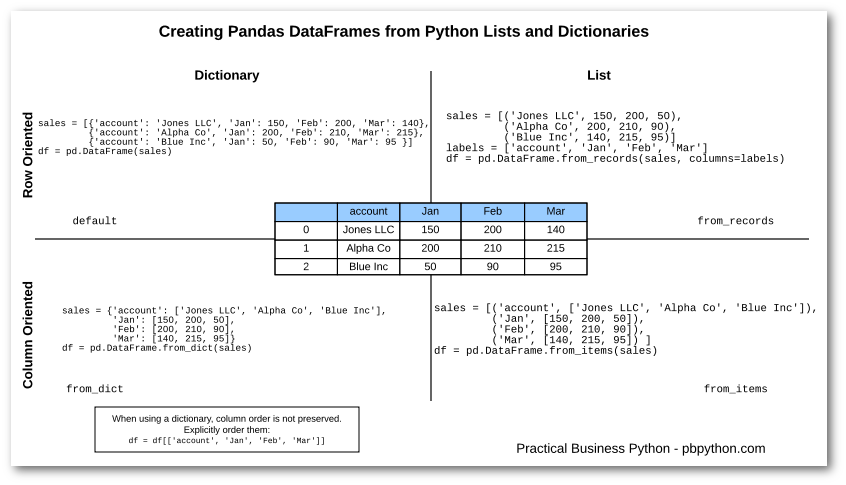

In [52]:
records = [{'account':'Jones LLC','Jan':150,'Feb':200,'Mar':140},
           {'account':'Alpha Co','Jan':200,'Feb':210,'Mar':215},
           {'account':'Blue Inc','Jan':50,'Feb':90,'Mar':95}]
records_df = pd.DataFrame(records)
records_df

,account,Jan,Feb,Mar
0,Jones LLC,150,200,140
1,Alpha Co,200,210,215
2,Blue Inc,50,90,95


## Simple Visualization

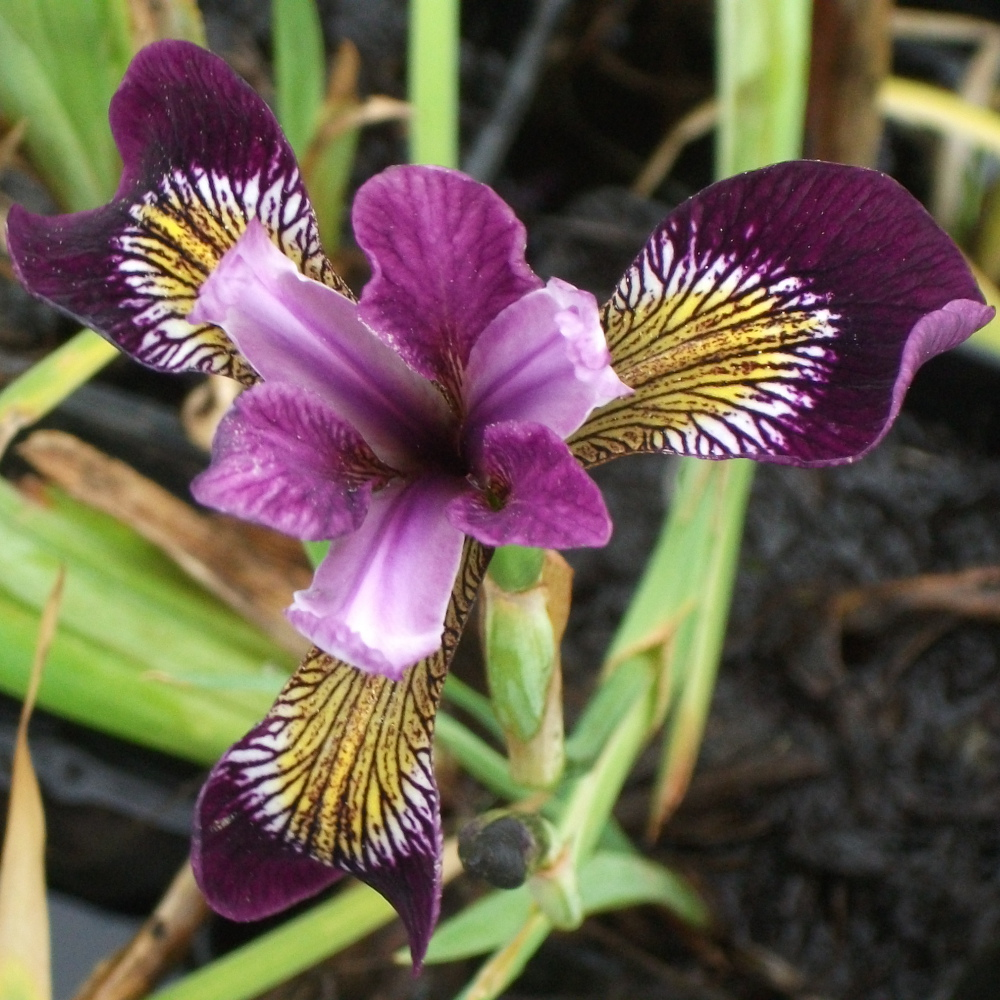

In [53]:
df = pd.read_csv('https://raw.github.com/pandas-dev/pandas/master/pandas/tests/io/data/csv/iris.csv')
df

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [54]:
df.groupby('Name').count()

,SepalLength,SepalWidth,PetalLength,PetalWidth
Name,,,,
Iris-setosa,50,50,50,50
Iris-versicolor,50,50,50,50
Iris-virginica,50,50,50,50


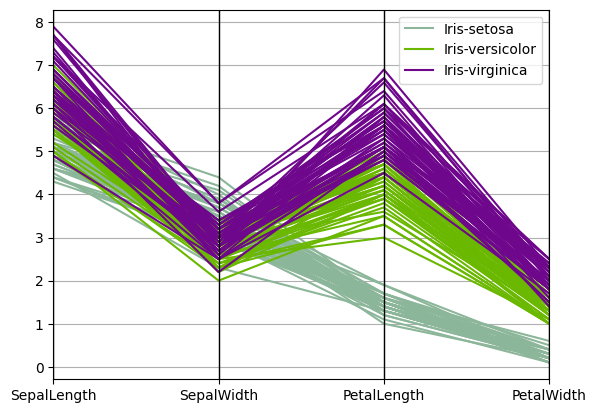

In [55]:
pd.plotting.parallel_coordinates(df, 'Name');

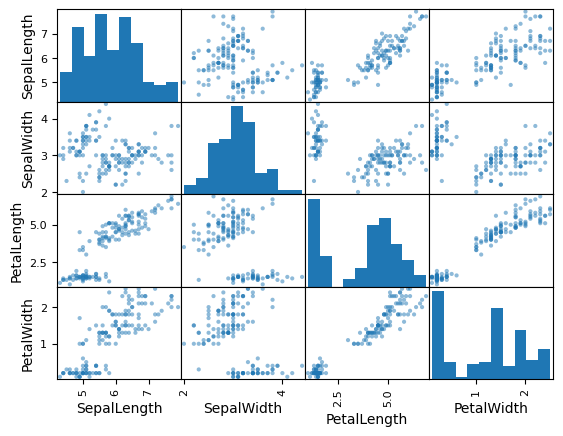

In [56]:
pd.plotting.scatter_matrix(df);

## save table

In [57]:
announce_date_count = missing_sex[missing_sex['risk']=='Cluster สมุทรสาคร'].groupby('announce_date').count()
announce_date_count

,No.,Notified date,sex,age,Unit,nationality,province_of_isolation,risk,province_of_onset,district_of_onset
announce_date,,,,,,,,,,


In [58]:
announce_date_count.to_csv('announce_date_count.csv')